In [ ]:
!pip install soundfile librosa s3prl whisper
!pip install -U git+https://github.com/wenet-e2e/wespeaker.git
!pip install huggingface-hub
!pip install pyroomacoustics==0.8.6 audiomentations==0.36.0
!pip install scipy==1.12.0
!pip install -U git+https://github.com/wenet-e2e/wespeaker.git
!pip install onnxruntime

In [2]:
# Cell 2: Model Loading Functions
import os
import sys
import yaml
import torch
import torch.nn as nn
from collections import OrderedDict
from wespeaker.models.speaker_model import get_speaker_model
from wespeaker.cli.hub import Hub

def load_model_pt(model_dir):
    if model_dir in Hub.Assets:
        model_dir = Hub.get_model(model_dir)
    
    # Load config
    with open(os.path.join(model_dir, 'config.yaml'), 'r') as f:
        config = yaml.load(f, Loader=yaml.FullLoader)
    
    # Create model structure from config
    model = get_speaker_model(config['model'])(**config['model_args'])
    
    return model, config

def load_resnet_from_checkpoint(ckpt_path, pretrained_dir, device='cuda'):
    print(f"Loading ResNet model from: {ckpt_path}")
    
    # 1. Load backbone architecture from pretrained config
    backbone, config = load_model_pt(pretrained_dir)
    
    # 2. Load finetuned checkpoint
    checkpoint = torch.load(ckpt_path, map_location='cpu')
    state_dict = checkpoint['state_dict'] if 'state_dict' in checkpoint else checkpoint
    
    # 3. Clean state_dict keys (Remove Lightning prefixes)
    new_state_dict = OrderedDict()
    for k, v in state_dict.items():
        # Remove prefixes like 'backbone.', 'model.', etc.
        if k.startswith(('backbone.', 'model.', 'speaker_model.', 'encoder.')):
            k = k.split('.', 1)[1]
        # Skip projection head / classifier weights (only keep encoder)
        if any(head in k for head in ['projection', 'classifier', 'margin', 'head', 'fc']):
            continue
        new_state_dict[k] = v
    
    # 4. Load weights into backbone
    missing, unexpected = backbone.load_state_dict(new_state_dict, strict=False)
    
    print(f"   Missing keys: {len(missing)}")
    print(f"   Unexpected keys: {len(unexpected)}")
    
    backbone.to(device)
    backbone.eval()
    return backbone

# Cấu hình thiết bị
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [3]:
# Cell 3: Feature Extraction Logic
import torchaudio.compliance.kaldi as kaldi
import numpy as np
import librosa
import torch
import torch.nn.functional as F

# Configs khớp với notebook mẫu
TARGET_SR = 16000
CHUNK_LEN = 3 * 16000  # 3 seconds
MIN_AUDIO_LENGTH = 0.5

def compute_fbank(waveform, sample_rate=16000, num_mel_bins=80, frame_length=25, frame_shift=10):
    feat = kaldi.fbank(waveform,
        num_mel_bins=num_mel_bins,
        frame_length=frame_length,
        frame_shift=frame_shift,
        sample_frequency=sample_rate,
        window_type='hamming')
    feat = feat - torch.mean(feat, 0) # CMN
    return feat

def preprocess_waveform_to_chunks(audio, sr, target_sr=TARGET_SR, chunk_len=CHUNK_LEN):
    # 1. Resample & Mono
    if sr != target_sr:
        audio = librosa.resample(audio, orig_sr=sr, target_sr=target_sr)
    if audio.ndim > 1:
        audio = np.mean(audio, axis=1)

    # 2. Chuyển thành Tensor và thêm chiều channel -> Shape: [1, Time]
    # (Cần shape 2D để dùng được hàm F.pad)
    pcm = torch.tensor(audio, dtype=torch.float32).unsqueeze(0)
    pcm = pcm * (1 << 15)  # Scale to int16 range like Kaldi expects

    chunks = []
    step_len = chunk_len // 2  # Overlap 50% (1.5 giây)
    current_len = pcm.size(1)

    # 3. Xử lý Audio ngắn (Zero Padding)
    if current_len < chunk_len:
        pad_amt = chunk_len - current_len
        # Đệm thêm số 0 vào cuối tensor
        padded_wav = F.pad(pcm, (0, pad_amt), "constant", 0)
        chunks.append(padded_wav)
        
    # 4. Xử lý Audio dài (Sliding Window với Overlap 50%)
    else:
        for start in range(0, current_len - chunk_len + 1, step_len):
            chunks.append(pcm[:, start:start + chunk_len])
            
        # Xử lý đoạn lẻ ở cuối cùng (nếu có) để không bỏ sót thông tin
        if (current_len - chunk_len) % step_len != 0:
            chunks.append(pcm[:, -chunk_len:])

    # Trả về list các tensor có shape [1, chunk_len]
    return chunks

def extract_embedding(model, file_path, device):
    try:
        # Load audio
        audio, sr = librosa.load(file_path, sr=None) # Load orig sr first
        chunks = preprocess_waveform_to_chunks(audio, sr)
        
        if not chunks: return None
        
        chunk_embeddings = []
        with torch.no_grad():
            for chunk in chunks:
                fbank = compute_fbank(chunk).unsqueeze(0).to(device) # [1, T, F]
                out = model(fbank)
                out = out[-1] if isinstance(out, tuple) else out
                chunk_embeddings.append(out.cpu())
        
        # Average embeddings from all chunks
        final_emb = torch.stack(chunk_embeddings).mean(dim=0)
        final_emb = F.normalize(final_emb, p=2, dim=1)
        return final_emb.squeeze(0) # [Dim]
        
    except Exception as e:
        print(f"Error extracting {file_path}: {e}")
        return None

In [4]:
# Cell 4: Initialize Model
PRETRAINED_DIR = "/kaggle/input/datasets/minhtu4n/samresnet34-pretrained-voxblink2" 
CKPT_PATH = "/kaggle/input/datasets/richardjacob04/samresnet34-full-10-04/simamresnet34_vivoice_finetuned_OLD.pt"
DATA_ROOT = "/kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet"

# Load Model
model = load_resnet_from_checkpoint(CKPT_PATH, PRETRAINED_DIR, DEVICE)
print("✅ Model loaded successfully!")

Loading ResNet model from: /kaggle/input/datasets/richardjacob04/samresnet34-full-10-04/simamresnet34_vivoice_finetuned_OLD.pt
   Missing keys: 0
   Unexpected keys: 0
✅ Model loaded successfully!


In [5]:
# Cell 5: Run Verification
from tqdm import tqdm
import pandas as pd

# 1. Tìm file CSV
TEST_LIST_PATH = os.path.join(DATA_ROOT, "test_list_gt_1.csv")
if not os.path.exists(TEST_LIST_PATH):
    # Fallback tìm kiếm
    for root, dirs, files in os.walk("/kaggle/input"):
        if "test_list_gt_1.csv" in files:
            TEST_LIST_PATH = os.path.join(root, "test_list_gt_1.csv")
            DATA_ROOT = root 
            break

print(f"Reading test list from: {TEST_LIST_PATH}")

# 2. Đọc pairs VÀ LỌC TRÙNG
pairs = []
seen_pairs = set() # Dùng set để theo dõi các cặp audio đã thêm vào list

with open(TEST_LIST_PATH, 'r', encoding='utf-8-sig') as f:
    for line in f:
        line = line.strip().replace('"', '')
        parts = line.split('\t')
        if len(parts) >= 3:
            label = int(parts[0])
            p1 = os.path.join(DATA_ROOT, parts[1].strip())
            p2 = os.path.join(DATA_ROOT, parts[2].strip())
            
            if os.path.exists(p1) and os.path.exists(p2):
                # Sắp xếp p1 và p2 để gom nhóm chung các cặp dạng (A, B) và (B, A)
                pair_identifier = tuple(sorted([p1, p2]))
                
                # Nếu cặp audio này chưa được đưa vào đánh giá thì mới xử lý tiếp
                if pair_identifier not in seen_pairs:
                    seen_pairs.add(pair_identifier)
                    pairs.append((p1, p2, label))

print(f"Found {len(pairs)} UNIQUE and valid pairs.")

# 3. Inference Loop
scores = []
labels = []
# Cache để tránh load/extract lại cùng 1 file nhiều lần (tối ưu tốc độ)
emb_cache = {} 

print("Starting inference...")
for p1, p2, label in tqdm(pairs):
    # Extract Emb 1
    if p1 not in emb_cache:
        emb1 = extract_embedding(model, p1, DEVICE)
        emb_cache[p1] = emb1
    else:
        emb1 = emb_cache[p1]
        
    # Extract Emb 2
    if p2 not in emb_cache:
        emb2 = extract_embedding(model, p2, DEVICE)
        emb_cache[p2] = emb2
    else:
        emb2 = emb_cache[p2]
    
    if emb1 is not None and emb2 is not None:
        # Compute Cosine Similarity
        score = torch.nn.functional.cosine_similarity(emb1.unsqueeze(0), emb2.unsqueeze(0)).item()
        scores.append(score)
        labels.append(label)

Reading test list from: /kaggle/input/datasets/minhtu4n/vox-o-vietnamese/VoxVietnameseFullTestSet/test_list_gt_1.csv
Found 8887 UNIQUE and valid pairs.
Starting inference...


100%|██████████| 8887/8887 [18:58<00:00,  7.81it/s] 



Model: SAM-ResNet34 (Finetuned)
Pairs evaluated: 8887
EER: 1.5757%
Threshold: 0.4090
AUC: 0.9976



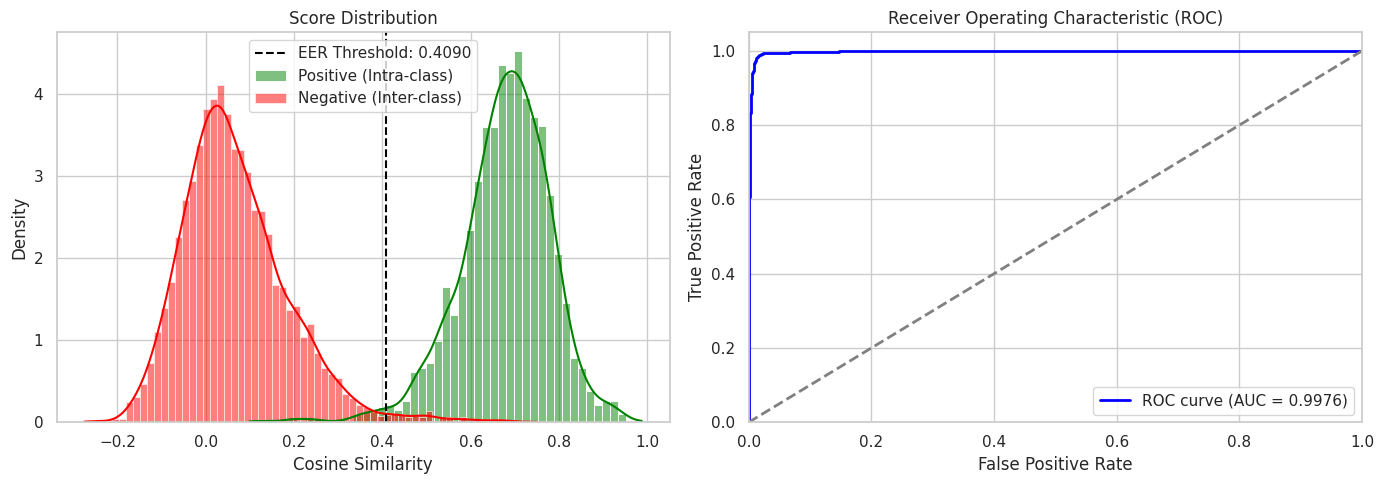

In [6]:
# Cell 6: Calculate EER & Visualize ROC/Score Distribution
from sklearn.metrics import roc_curve, auc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def compute_eer(labels, scores):
    fpr, tpr, thresholds = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    eer_threshold = thresholds[np.nanargmin(np.absolute((fnr - fpr)))]
    eer = fpr[np.nanargmin(np.absolute((fnr - fpr)))]
    return eer * 100, eer_threshold, fpr, tpr

if len(scores) > 0:
    eer, thresh, fpr, tpr = compute_eer(labels, scores)
    roc_auc = auc(fpr, tpr)
    
    print(f"\n==========================================")
    print(f"Model: SAM-ResNet34 (Finetuned)")
    print(f"Pairs evaluated: {len(scores)}")
    print(f"EER: {eer:.4f}%")
    print(f"Threshold: {thresh:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    print(f"==========================================\n")
    
    # Lưu kết quả
    df = pd.DataFrame({"score": scores, "label": labels})
    df.to_csv("samresnet_verification_results.csv", index=False)
    
    # ---------------- BỔ SUNG VISUALIZE ---------------- #
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 5))
    
    # 1. Score Distribution (Histogram)
    plt.subplot(1, 2, 1)
    sns.histplot(data=df[df['label']==1], x='score', color='green', label='Positive (Intra-class)', kde=True, stat='density', alpha=0.5)
    sns.histplot(data=df[df['label']==0], x='score', color='red', label='Negative (Inter-class)', kde=True, stat='density', alpha=0.5)
    plt.axvline(thresh, color='black', linestyle='--', label=f'EER Threshold: {thresh:.4f}')
    plt.title('Score Distribution')
    plt.xlabel('Cosine Similarity')
    plt.ylabel('Density')
    plt.legend()
    
    # 2. ROC Curve
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc="lower right")
    
    plt.tight_layout()
    plt.savefig('eer_analysis.png', dpi=150)
    plt.show()
    
else:
    print("No scores computed. Check dataset paths.")

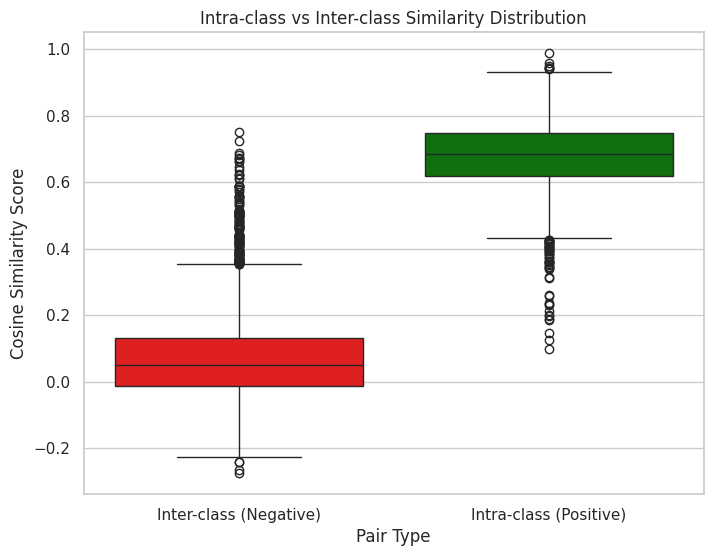

In [8]:
# Cell 7: Intra-class vs Inter-class Distance Boxplot
if len(scores) > 0:
    plt.figure(figsize=(8, 6))
    
    # Sửa lỗi: Thêm hue='label', legend=False và cập nhật key cho palette bao gồm cả dạng chuỗi và số
    sns.boxplot(
        x='label', 
        y='score', 
        hue='label', 
        data=df, 
        palette={1: 'green', 0: 'red', '1': 'green', '0': 'red'}, 
        legend=False
    )
    
    plt.xticks([0, 1], ['Inter-class (Negative)', 'Intra-class (Positive)'])
    plt.title('Intra-class vs Inter-class Similarity Distribution')
    plt.ylabel('Cosine Similarity Score')
    plt.xlabel('Pair Type')
    plt.savefig('intra_inter_boxplot.png', dpi=150)
    plt.show()

Total extracted embeddings for visualization: 17774
Total unique speakers: 1
Visualizing 1 speakers, 17774 samples


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1945: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")
/usr/local/lib/python3.12/dist-packages/umap/spectral.py:550: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


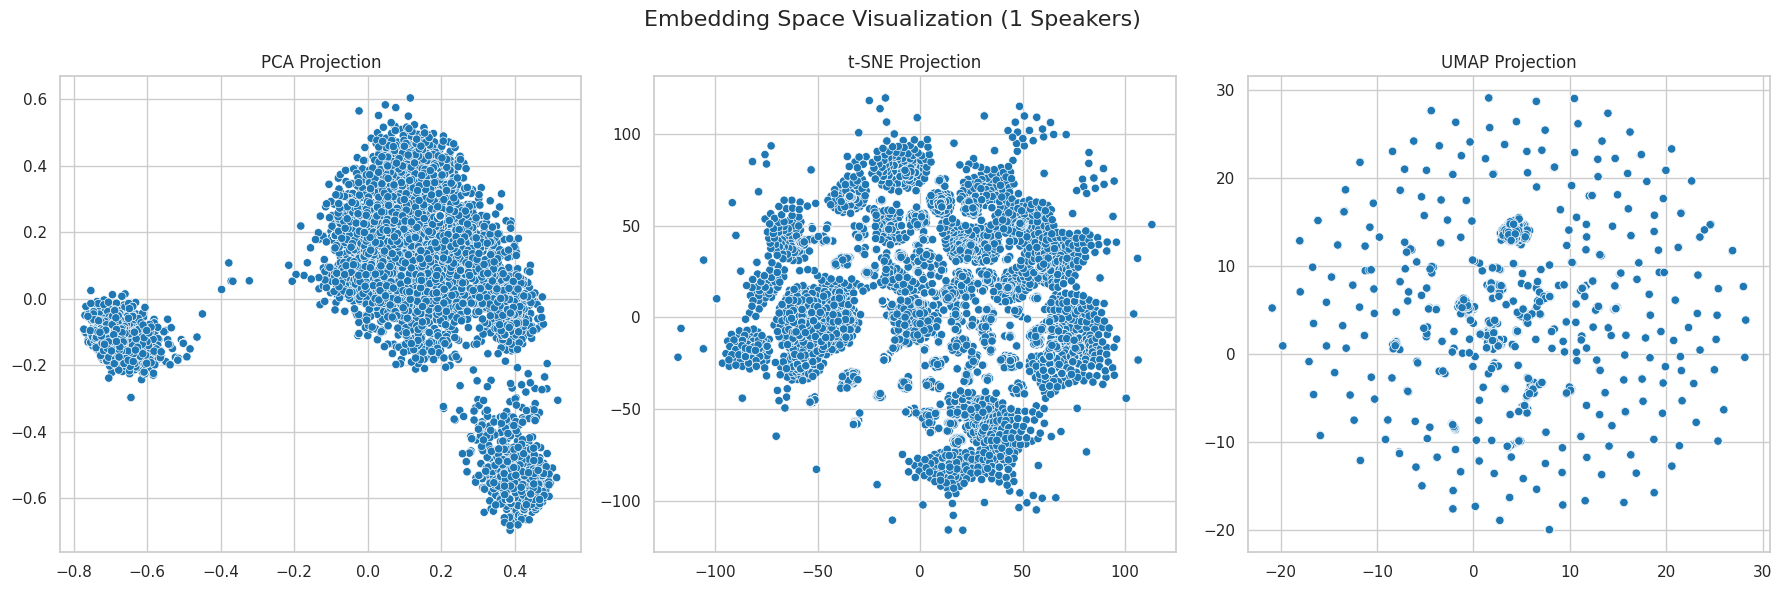

In [9]:
# Cell 8: PCA / t-SNE / UMAP Visualization
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import umap

# 1. Trích xuất Embeddings và Labels từ emb_cache
embeddings_list = []
speaker_labels = []

for path, emb in emb_cache.items():
    embeddings_list.append(emb.cpu().numpy())
    # Lấy Speaker ID dựa trên tên thư mục chứa file wav
    spk_id = os.path.basename(os.path.dirname(path))
    speaker_labels.append(spk_id)

embeddings_np = np.array(embeddings_list)
speaker_labels = np.array(speaker_labels)

unique_speakers = np.unique(speaker_labels)
print(f"Total extracted embeddings for visualization: {len(embeddings_np)}")
print(f"Total unique speakers: {len(unique_speakers)}")

# 2. Chọn N speakers ngẫu nhiên (nhiều sample) để hình không bị rối
NUM_SPEAKERS_VIS = 20
if len(unique_speakers) > NUM_SPEAKERS_VIS:
    label_counts = {spk: (speaker_labels == spk).sum() for spk in unique_speakers}
    top_speakers = sorted(label_counts, key=label_counts.get, reverse=True)[:NUM_SPEAKERS_VIS]
else:
    top_speakers = unique_speakers

mask = np.isin(speaker_labels, top_speakers)
vis_embeds = embeddings_np[mask]
vis_labels = speaker_labels[mask]

print(f"Visualizing {len(top_speakers)} speakers, {len(vis_embeds)} samples")

# 3. Chạy PCA, t-SNE và UMAP
if len(vis_embeds) > 0:
    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(vis_embeds)

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=min(30, len(vis_embeds)-1), random_state=42)
    tsne_result = tsne.fit_transform(vis_embeds)
    
    # UMAP
    try:
        umap_reducer = umap.UMAP(n_components=2, random_state=42)
        umap_result = umap_reducer.fit_transform(vis_embeds)
        has_umap = True
    except:
        has_umap = False

    # 4. Plot kết quả
    fig, axes = plt.subplots(1, 3 if has_umap else 2, figsize=(18 if has_umap else 12, 6))
    
    sns.scatterplot(x=pca_result[:,0], y=pca_result[:,1], hue=vis_labels, ax=axes[0], palette='tab20', legend=False)
    axes[0].set_title('PCA Projection')
    
    sns.scatterplot(x=tsne_result[:,0], y=tsne_result[:,1], hue=vis_labels, ax=axes[1], palette='tab20', legend=False)
    axes[1].set_title('t-SNE Projection')
    
    if has_umap:
        sns.scatterplot(x=umap_result[:,0], y=umap_result[:,1], hue=vis_labels, ax=axes[2], palette='tab20', legend=False)
        axes[2].set_title('UMAP Projection')
        
    plt.suptitle(f'Embedding Space Visualization ({len(top_speakers)} Speakers)', fontsize=16)
    plt.tight_layout()
    plt.savefig('tsne_pca_umap.png', dpi=150)
    plt.show()

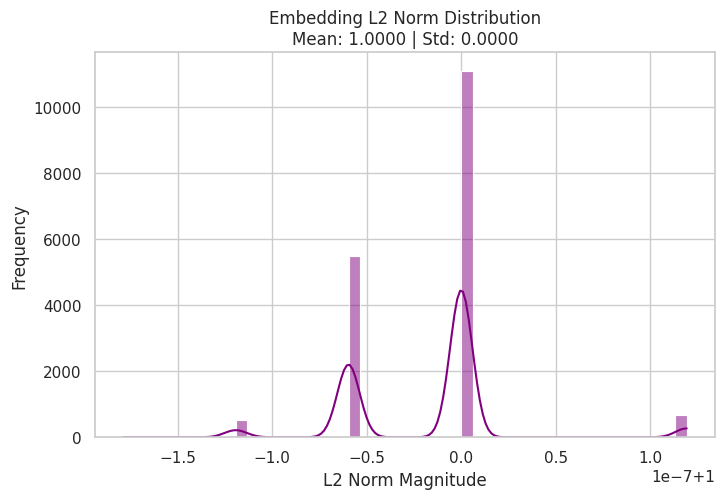

In [10]:
# Cell 9: Embedding Norm Distribution
if len(embeddings_np) > 0:
    norms = np.linalg.norm(embeddings_np, axis=1)

    plt.figure(figsize=(8, 5))
    sns.histplot(norms, kde=True, color='purple', bins=50)
    plt.title(f'Embedding L2 Norm Distribution\nMean: {norms.mean():.4f} | Std: {norms.std():.4f}')
    plt.xlabel('L2 Norm Magnitude')
    plt.ylabel('Frequency')
    plt.savefig('embedding_norms.png', dpi=150)
    plt.show()